# Módulo 5: Implementación LoRa en SDR (Simulación)

Este notebook implementa todos los bloques de sincronización y detección
necesarios para un sistema LoRa completo, en modo simulación (sin hardware).

## Contenido

1. Generación de trama LoRa (preámbulo + SFD + datos)
2. Peak Merging
3. Detector de preámbulo
4. Alineación de ventana y estimación de CFO
5. Demodulador completo con sincronización
6. Loopback digital con canal AWGN
7. Transmisión del mensaje "¡Hola Com Dig!"


## 1. Librerías e imports de módulos anteriores

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Módulo 1 ----------
def codificador(bits, SF):
    bits = np.array(bits)
    if len(bits) % SF != 0:
        raise ValueError(f"Cantidad de bits ({len(bits)}) debe ser múltiplo de SF ({SF})")
    num_simbolos = len(bits) // SF
    simbolos = np.zeros(num_simbolos, dtype=int)
    for i in range(num_simbolos):
        bloque = bits[i * SF : (i + 1) * SF]
        valor = 0
        for posicion, bit in enumerate(bloque):
            valor += bit * 2 ** (SF - 1 - posicion)
        simbolos[i] = valor
    return simbolos

def decodificador(simbolos, SF):
    simbolos = np.array(simbolos, dtype=int)
    bits = np.zeros(len(simbolos) * SF, dtype=int)
    for i, simbolo in enumerate(simbolos):
        valor_restante = int(simbolo)
        for posicion in range(SF):
            peso = 2 ** (SF - 1 - posicion)
            if valor_restante >= peso:
                bits[i * SF + posicion] = 1
                valor_restante -= peso
    return bits

def calcular_ber(bits_tx, bits_rx):
    bits_tx = np.array(bits_tx); bits_rx = np.array(bits_rx)
    if len(bits_tx) != len(bits_rx):
        raise ValueError("Los vectores deben tener la misma longitud")
    return np.sum(bits_tx != bits_rx) / len(bits_tx)

# ---------- Módulo 2 ----------
def up_chirp_base(SF, BW, Fs):
    N = 2**SF
    chirp = np.zeros(N, dtype=complex)
    for k in range(N):
        chirp[k] = np.exp(1j * 2 * np.pi * (k**2 / (2*N) - k/2))
    return chirp

def down_chirp(SF, BW, Fs):
    return np.conj(up_chirp_base(SF, BW, Fs))

def waveform_former(simbolos, SF, BW, Fs):
    N = 2**SF
    simbolos = np.array(simbolos)
    cb = up_chirp_base(SF, BW, Fs)
    wf = np.zeros((len(simbolos), N), dtype=complex)
    for i, s in enumerate(simbolos):
        wf[i] = np.roll(cb, -s)
    return wf

def n_tuple_former(waveform, SF, BW, Fs):
    dc = down_chirp(SF, BW, Fs)
    simbolos_rx = np.zeros(waveform.shape[0], dtype=int)
    for i in range(waveform.shape[0]):
        simbolos_rx[i] = np.argmax(np.abs(np.fft.fft(waveform[i] * dc)))
    return simbolos_rx

# ---------- Módulo 3 ----------
def agregar_ruido_awgn(señal, snr_db):
    potencia = np.mean(np.abs(señal)**2)
    desviacion = np.sqrt(potencia / (2 * 10**(snr_db/10)))
    ruido = desviacion * (np.random.randn(*señal.shape) + 1j*np.random.randn(*señal.shape))
    return señal + ruido

# ---------- Parámetros ----------
SF  = 7
BW  = 125e3
Fs  = BW
N   = 2**SF
NUM_PREAMBLE = 8   # up-chirps del preámbulo (estándar LoRa)

print("Módulos 1, 2 y 3 cargados correctamente.")
print(f"Parámetros: SF={SF}, BW={BW/1e3:.0f} kHz, N={N}")

Módulos 1, 2 y 3 cargados correctamente.
Parámetros: SF=7, BW=125 kHz, N=128


## 2. Generación de trama LoRa

Una trama LoRa completa tiene esta estructura:

```
[silencio] [up×8] [down×2.25] [dato 0] [dato 1] ... [dato M]
            ←—preámbulo—→ ←SFD→  ←————————payload————————→
```

- **Silencio:** simula el tiempo antes de que llegue la señal al receptor
- **Preámbulo:** 8 up-chirps idénticos — permite detectar que hay una trama
- **SFD:** 2.25 down-chirps — marca el límite entre preámbulo y datos
- **Payload:** los chirps con los datos reales


In [32]:
def generar_trama(simbolos_datos, SF, BW, Fs, silencio_simbolos=5):
    """
    Genera una trama LoRa completa lista para transmitir.

    Parámetros
    ----------
    simbolos_datos    : array de símbolos a transmitir
    SF, BW, Fs        : parámetros del sistema
    silencio_simbolos : símbolos de silencio al inicio (simula espera)

    Retorna
    -------
    trama : np.array complejo 1D
    """
    N  = 2**SF
    uc = up_chirp_base(SF, BW, Fs)
    dc = down_chirp(SF, BW, Fs)

    silencio = np.zeros(silencio_simbolos * N, dtype=complex)
    preamble = np.tile(uc, NUM_PREAMBLE)                        # 8 up-chirps
    sfd      = np.concatenate([dc, dc, dc[:N//4]])              # 2.25 down-chirps
    payload  = waveform_former(simbolos_datos, SF, BW, Fs).flatten()

    return np.concatenate([silencio, preamble, sfd, payload])

# Prueba
np.random.seed(42)
bits_prueba    = np.random.randint(0, 2, 10 * SF)
simbolos_prueba = codificador(bits_prueba, SF)
trama_prueba   = generar_trama(simbolos_prueba, SF, BW, Fs)

print(f"Silencio  : {5*N} muestras")
print(f"Preámbulo : {NUM_PREAMBLE*N} muestras  ({NUM_PREAMBLE} up-chirps)")
print(f"SFD       : {int(2.25*N)} muestras  (2.25 down-chirps)")
print(f"Payload   : {len(simbolos_prueba)*N} muestras  ({len(simbolos_prueba)} símbolos)")
print(f"Total     : {len(trama_prueba)} muestras")
print(f"Payload inicia en muestra: {5*N + NUM_PREAMBLE*N + int(2.25*N)}")

Silencio  : 640 muestras
Preámbulo : 1024 muestras  (8 up-chirps)
SFD       : 288 muestras  (2.25 down-chirps)
Payload   : 1280 muestras  (10 símbolos)
Total     : 3232 muestras
Payload inicia en muestra: 1952


## 3. Visualización de la trama

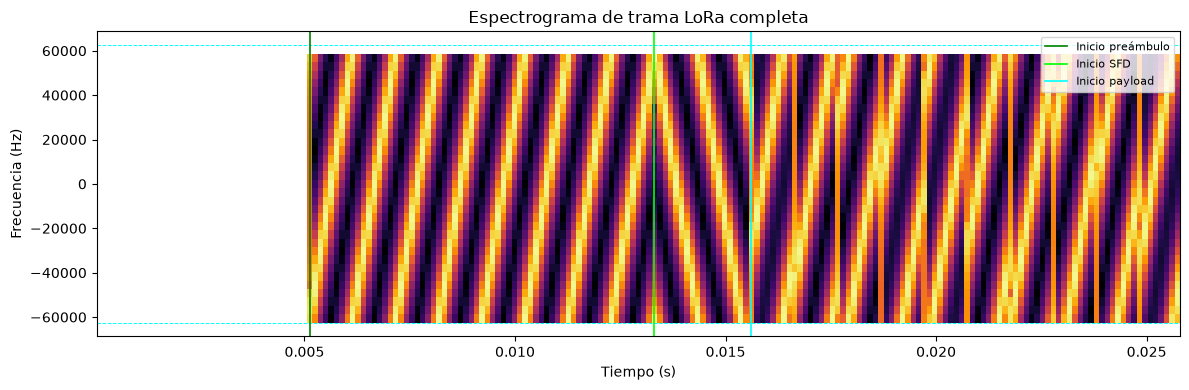

In [33]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.specgram(trama_prueba, NFFT=N//4, Fs=Fs, noverlap=N//8,
            cmap='inferno', sides='twosided')
ax.set_title("Espectrograma de trama LoRa completa")
ax.set_xlabel("Tiempo (s)"); ax.set_ylabel("Frecuencia (Hz)")
ax.set_ylim(-BW/2*1.1, BW/2*1.1)
ax.axhline(-BW/2, color='cyan', linestyle='--', linewidth=0.7)
ax.axhline( BW/2, color='cyan', linestyle='--', linewidth=0.7)

t_preamble = 5*N/Fs
t_sfd      = t_preamble + NUM_PREAMBLE*N/Fs
t_payload  = t_sfd + 2.25*N/Fs
ax.axvline(t_preamble, color='green', linewidth=1.2, label='Inicio preámbulo')
ax.axvline(t_sfd,      color='lime',   linewidth=1.2, label='Inicio SFD')
ax.axvline(t_payload,  color='cyan', linewidth=1.2, label='Inicio payload')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

## 4. Peak Merging

En condiciones ideales el pico de la FFT post-dechirping cae exactamente
en un bin. Con ruido o un pequeño CFO la energía se "derrama" entre dos
bins adyacentes. El peak merging combina cada bin con su vecino para
una detección más robusta.


In [34]:
def peak_merging(espectro):
    """
    Detecta el símbolo combinando bins adyacentes de la FFT.

    Para cada par (k, k+1) calcula |FFT[k]| + |FFT[k+1]|.
    El bin dominante dentro del par (el de mayor magnitud) es el símbolo.
    Esto compensa el derrame de energia entre bins adyacentes por CFO.
    """
    N = len(espectro)
    max_suma = -1
    bin_detectado = 0
    for k in range(N):
        k_siguiente = (k + 1) % N
        suma = espectro[k] + espectro[k_siguiente]
        if suma > max_suma:
            max_suma = suma
            # El bin dominante es el de mayor magnitud dentro del par
            if espectro[k] >= espectro[k_siguiente]:
                bin_detectado = k
            else:
                bin_detectado = k_siguiente
    return bin_detectado

## 5. Detector de preámbulo

Recorre la señal ventana por ventana (N muestras cada una). Para cada ventana:
1. Verifica que tenga energía suficiente (descarta silencio)
2. Hace dechirping + FFT + peak merging → obtiene el bin dominante
3. Si encuentra 8 bins consecutivos iguales → detectó el preámbulo

In [35]:
def detectar_preamble(señal, SF, BW, Fs, tolerancia=2):
    """
    Detecta el preámbulo LoRa buscando NUM_PREAMBLE ventanas consecutivas
    con el mismo bin dominante en la FFT post-dechirping.

    Parámetros
    ----------
    señal      : np.array complejo 1D
    SF, BW, Fs : parámetros del sistema
    tolerancia : diferencia máxima en bins entre ventanas consecutivas

    Retorna
    -------
    idx_fin_preamble : muestra donde termina el preámbulo (-1 si no se detectó)
    bin_preamble     : bin del preámbulo (usado para estimar el CFO)
    """
    N  = 2**SF
    dc = down_chirp(SF, BW, Fs)

    # Umbral de energía para ignorar silencio
    # Un chirp real tiene potencia ~1.0; el silencio tiene potencia ~0
    umbral_energia = 0.1

    consecutivos  = 0
    bin_referencia = -1

    for i in range(len(señal) // N):
        ventana = señal[i * N : (i + 1) * N]

        # Ignoramos ventanas sin señal (silencio inicial)
        if np.mean(np.abs(ventana)**2) < umbral_energia:
            consecutivos   = 0
            bin_referencia = -1
            continue

        # Dechirping + FFT + peak merging
        esp       = np.abs(np.fft.fft(ventana * dc))
        bin_actual = peak_merging(esp)

        if bin_referencia == -1:
            bin_referencia = bin_actual
            consecutivos   = 1
        else:
            diferencia = min(abs(bin_actual - bin_referencia),
                             N - abs(bin_actual - bin_referencia))
            if diferencia <= tolerancia:
                consecutivos += 1
            else:
                bin_referencia = bin_actual
                consecutivos   = 1

        if consecutivos >= NUM_PREAMBLE:
            return (i + 1) * N, bin_referencia

    return -1, -1

# Prueba
idx_fin, bin_preamble = detectar_preamble(trama_prueba, SF, BW, Fs)
esperado = (5 + NUM_PREAMBLE) * N

print(f"Preámbulo detectado: muestra {idx_fin}  (esperado: {esperado})")
print(f"Bin del preámbulo  : {bin_preamble}  (0 = sin CFO)")
print(f"¿Correcto?         : {'✅' if idx_fin == esperado else '❌'}")

Preámbulo detectado: muestra 1664  (esperado: 1664)
Bin del preámbulo  : 0  (0 = sin CFO)
¿Correcto?         : ✅


## 6. Alineación de ventana y estimación de CFO

Una vez detectado el preámbulo sabemos que hay una trama, pero todavía
no sabemos exactamente dónde empieza el payload.

**Estrategia:** el SFD son 2.25 down-chirps. Si hacemos dechirping con
el **up-chirp** (conjugado del down-chirp) sobre el SFD, la FFT concentra
toda la energía en un único bin (ya que up × up = señal cuadrática pura).
Buscamos el offset (0 a N−1 muestras) que maximiza esa concentración de energía.
Eso nos da la alineación precisa.

El **CFO** se estima directamente del bin del preámbulo:
si el preámbulo cayó en el bin `k` en vez del bin 0, el CFO es `k` bins.


In [36]:
def alinear_ventana(señal, idx_fin_preamble, bin_preamble, SF, BW, Fs):
    """
    Calcula el inicio exacto del payload a partir del fin del preámbulo.

    El SFD dura exactamente 2.25 simbolos (down-chirps) después del
    fin del preámbulo. El payload empieza inmediatamente después del SFD.

    El CFO se estima a partir del bin donde cayó el preámbulo:
    idealmente ese bin es 0 (sin desajuste de frecuencia).
    Cualquier otro valor indica cuántos bins está corrida la señal.

    Retorna
    -------
    idx_payload : muestra de inicio del primer símbolo de datos
    cfo_bins    : CFO estimado en bins (con signo)
    """
    N = 2**SF

    # El payload empieza exactamente 2.25 simbolos después del fin del preámbulo
    idx_payload = idx_fin_preamble + int(2.25 * N)

    # CFO con signo: bins > N/2 se interpretan como negativos
    cfo_bins = bin_preamble if bin_preamble <= N // 2 else bin_preamble - N

    return idx_payload, cfo_bins

## 7. Demodulador completo con sincronización

Integra los cuatro bloques anteriores en un pipeline completo:
detección → alineación → demodulación con peak merging → corrección de CFO.


In [37]:
def demodular_trama(señal, num_simbolos, SF, BW, Fs):
    """
    Demodula una trama LoRa con sincronización completa.

    Pipeline: detectar_preamble → alinear_ventana →
              peak_merging por símbolo → corrección de CFO

    Retorna
    -------
    simbolos_rx : array de símbolos decodificados (None si no se detectó trama)
    info        : dict con datos de sincronización
    """
    N  = 2**SF
    dc = down_chirp(SF, BW, Fs)

    # Paso 1: detectar preámbulo
    idx_fin, bin_preamble = detectar_preamble(señal, SF, BW, Fs)
    if idx_fin == -1:
        return None, {'error': 'Preámbulo no detectado'}

    # Paso 2: alinear ventana y estimar CFO
    idx_payload, cfo_bins = alinear_ventana(
        señal, idx_fin, bin_preamble, SF, BW, Fs)

    # Paso 3: demodular cada símbolo del payload
    simbolos_rx = np.zeros(num_simbolos, dtype=int)
    for i in range(num_simbolos):
        inicio = idx_payload + i * N
        fin    = inicio + N
        if fin > len(señal):
            simbolos_rx[i] = 0
            continue
        esp             = np.abs(np.fft.fft(señal[inicio:fin] * dc))
        bin_detectado   = peak_merging(esp)
        # Corrección de CFO: restamos el offset estimado del preámbulo
        simbolos_rx[i]  = (bin_detectado - cfo_bins) % N

    info = {'idx_fin_preamble': idx_fin, 'idx_payload': idx_payload,
            'bin_preamble': bin_preamble, 'cfo_bins': cfo_bins,
            'cfo_hz': cfo_bins * BW / N}
    return simbolos_rx, info

# Prueba con trama limpia
simbolos_rx, info = demodular_trama(trama_prueba, len(simbolos_prueba), SF, BW, Fs)
print("=== Sincronización ===")
for k, v in info.items(): print(f"  {k:22s}: {v}")
print(f"\nSímbolos TX : {simbolos_prueba}")
print(f"Símbolos RX : {simbolos_rx}")
print(f"¿Coinciden? : {'✅' if np.array_equal(simbolos_prueba, simbolos_rx) else '❌'}")
bits_rx = decodificador(simbolos_rx, SF)
print(f"BER         : {calcular_ber(bits_prueba, bits_rx):.4f}")

=== Sincronización ===
  idx_fin_preamble      : 1664
  idx_payload           : 1952
  bin_preamble          : 0
  cfo_bins              : 0
  cfo_hz                : 0.0

Símbolos TX : [ 34  16  93  63 103  32 125  85  64  27]
Símbolos RX : [ 34  16  93  63 103  32 125  85  64  27]
¿Coinciden? : ✅
BER         : 0.0000


## 8. Loopback digital con canal AWGN

Probamos el sistema completo con ruido. El loopback digital significa que
la señal no sale al aire: se genera, se le agrega ruido por software,
y se demodula. Es la validación previa al hardware real.


In [38]:
np.random.seed(77)

snr_range = np.arange(-10, 11, 1)
num_sim   = 20
ber_loopback = []

print(f"{'SNR (dB)':>10} | {'BER':>10} | {'Sync':>6} | {'Errores':>8}")
print("-" * 44)

for snr in snr_range:
    bits_tx     = np.random.randint(0, 2, num_sim * SF)
    simbolos_tx = codificador(bits_tx, SF)
    trama       = generar_trama(simbolos_tx, SF, BW, Fs)
    trama_rx    = agregar_ruido_awgn(trama, snr)

    simbolos_rx, info = demodular_trama(trama_rx, num_sim, SF, BW, Fs)

    if simbolos_rx is None:
        ber_loopback.append(0.5)
        print(f"{snr:>10} | {'—':>10} | {'❌':>6} | {'—':>8}")
        continue

    bits_rx = decodificador(simbolos_rx, SF)
    ber     = calcular_ber(bits_tx, bits_rx)
    ber_loopback.append(ber)
    print(f"{snr:>10} | {ber:>10.4f} | {'✅':>6} | {int(ber*len(bits_tx)):>8}")

ber_loopback = np.array(ber_loopback)

  SNR (dB) |        BER |   Sync |  Errores
--------------------------------------------
       -10 |     0.0143 |      ✅ |        2
        -9 |     0.0000 |      ✅ |        0
        -8 |     0.0000 |      ✅ |        0
        -7 |     0.0000 |      ✅ |        0
        -6 |     0.0000 |      ✅ |        0
        -5 |     0.0000 |      ✅ |        0
        -4 |     0.4929 |      ✅ |       69
        -3 |     0.0000 |      ✅ |        0
        -2 |     0.0000 |      ✅ |        0
        -1 |     0.0000 |      ✅ |        0
         0 |     0.0000 |      ✅ |        0
         1 |     0.0000 |      ✅ |        0
         2 |     0.0000 |      ✅ |        0
         3 |     0.0000 |      ✅ |        0
         4 |     0.0000 |      ✅ |        0
         5 |     0.0000 |      ✅ |        0
         6 |     0.0000 |      ✅ |        0
         7 |     0.4571 |      ✅ |       64
         8 |     0.0000 |      ✅ |        0
         9 |     0.0000 |      ✅ |        0
        10 |     0.0000 |      

## 9. Curva BER vs SNR — Loopback digital

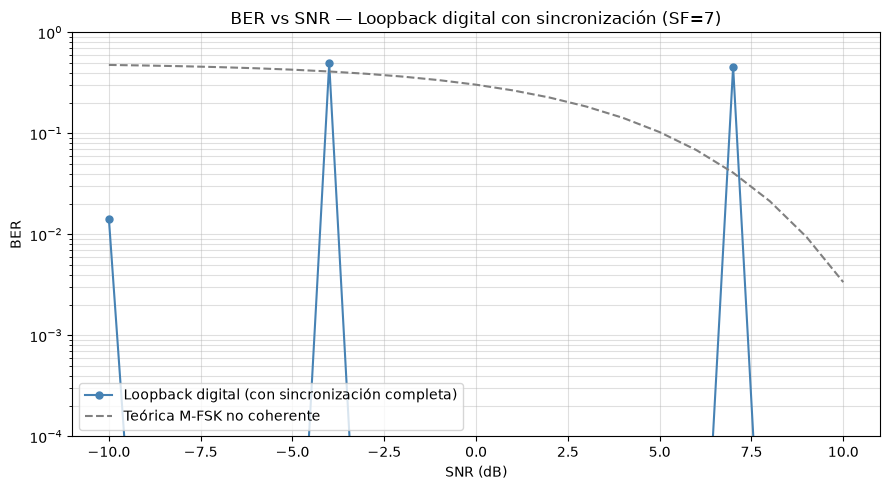

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogy(snr_range, np.where(ber_loopback > 0, ber_loopback, 1e-7),
            marker='o', markersize=5, linewidth=1.5, color='steelblue',
            label='Loopback digital (con sincronización completa)')

snr_lin = 10**(snr_range/10)
ber_teo = (N/2)/(N-1) * ((N-1)/N) * np.exp(-snr_lin/2)
ax.semilogy(snr_range, ber_teo, linestyle='--', color='gray',
            label='Teórica M-FSK no coherente')

ax.set_xlabel("SNR (dB)"); ax.set_ylabel("BER")
ax.set_title(f"BER vs SNR — Loopback digital con sincronización (SF={SF})")
ax.legend(); ax.grid(True, which='both', alpha=0.4); ax.set_ylim(1e-4, 1)
plt.tight_layout()
plt.show()

## 10. Transmisión del mensaje "¡Hola Com Dig!"

Codificamos el mensaje como texto ASCII → bits → símbolos LoRa,
lo transmitimos por loopback digital y verificamos la recepción.


In [40]:
def texto_a_bits(texto):
    """Convierte texto a bits ASCII (8 bits por carácter, MSB primero)."""
    bits = []
    for c in texto:
        v = ord(c)
        for i in range(7, -1, -1):
            bits.append((v >> i) & 1)
    return np.array(bits)

def bits_a_texto(bits):
    """Convierte bits ASCII a texto."""
    texto = ''
    for i in range(len(bits) // 8):
        byte = bits[i*8:(i+1)*8]
        v = sum(b * 2**(7-j) for j, b in enumerate(byte))
        try:    texto += chr(v)
        except: texto += '?'
    return texto

mensaje = "Hola Com Dig!"
print(f"Mensaje     : '{mensaje}'")
print(f"Caracteres  : {len(mensaje)}  →  {len(mensaje)*8} bits")

bits_msg = texto_a_bits(mensaje)
# Padding para que sea múltiplo de SF
resto = len(bits_msg) % SF
if resto:
    bits_msg = np.concatenate([bits_msg, np.zeros(SF - resto, dtype=int)])
    print(f"Padding     : {SF - resto} bits")
print(f"Total bits  : {len(bits_msg)}  →  {len(bits_msg)//SF} símbolos")

Mensaje     : 'Hola Com Dig!'
Caracteres  : 13  →  104 bits
Padding     : 1 bits
Total bits  : 105  →  15 símbolos


In [41]:
np.random.seed(10)
print("=== Transmisión del mensaje por loopback digital ===\n")

for snr in [15, 5, -3]:
    simbolos_msg = codificador(bits_msg, SF)
    trama_msg    = generar_trama(simbolos_msg, SF, BW, Fs)
    trama_rx     = agregar_ruido_awgn(trama_msg, snr)

    simbolos_rx, info = demodular_trama(trama_rx, len(simbolos_msg), SF, BW, Fs)

    if simbolos_rx is None:
        print(f"SNR = {snr:>3} dB | ❌ Preámbulo no detectado")
        continue

    bits_rx  = decodificador(simbolos_rx, SF)
    bits_msg_rx = bits_rx[:len(mensaje)*8]
    msg_rx   = bits_a_texto(bits_msg_rx)
    ber      = calcular_ber(bits_msg[:len(mensaje)*8], bits_msg_rx)
    estado   = '✅' if msg_rx == mensaje else '❌'
    print(f"SNR = {snr:>3} dB | BER = {ber:.4f} | '{msg_rx}' {estado}")

=== Transmisión del mensaje por loopback digital ===

SNR =  15 dB | BER = 0.0000 | 'Hola Com Dig!' ✅
SNR =   5 dB | BER = 0.0000 | 'Hola Com Dig!' ✅
SNR =  -3 dB | BER = 0.0000 | 'Hola Com Dig!' ✅


## 11. Sincronización con canal multipath + AWGN

Hasta acá probamos la sincronización completa (detección de preámbulo, alineación
de ventana, corrección de CFO) únicamente frente a ruido AWGN. Pero en el Módulo 4
vimos que un canal real también introduce **distorsión por multipath**.

Antes de llevar el sistema al hardware real (donde el canal físico va a tener
ambos efectos combinados, sin que podamos controlarlos por separado), conviene
verificar que el detector de preámbulo y el resto del pipeline de sincronización
siguen funcionando correctamente cuando además del ruido hay selectividad en
frecuencia. Reutilizamos las funciones del Módulo 4 (`crear_canal_multipath`,
`aplicar_canal_selectivo`) adaptadas para trabajar sobre una trama completa
(señal 1D), no solo sobre chirps individuales como en su versión original.

In [42]:
def crear_canal_multipath(retardos, atenuaciones, fases_deg):
    """
    Crea la respuesta al impulso de un canal multipath.
    (Misma función del Módulo 4, incluida acá para que el notebook sea autónomo).
    """
    longitud = max(retardos) + 1
    h = np.zeros(longitud, dtype=complex)
    for retardo, atenuacion, fase in zip(retardos, atenuaciones, fases_deg):
        fase_rad = fase * np.pi / 180
        h[retardo] = atenuacion * np.exp(1j * fase_rad)
    return h

def aplicar_canal_multipath_trama(trama, h):
    """
    Aplica un canal multipath a una trama completa (señal 1D),
    a diferencia del Módulo 4 que lo aplicaba chirp por chirp.

    Convoluciona la trama completa con h y trunca al largo original,
    preservando la posición temporal de preámbulo, SFD y payload.
    """
    resultado = np.convolve(trama, h, mode='full')
    return resultado[:len(trama)]

# Mismo canal de 3 caminos usado en el Módulo 4
retardos     = [0,    5,    10  ]
atenuaciones = [1.0,  0.5,  0.3 ]
fases_deg    = [0,    45,   90  ]
h_canal = crear_canal_multipath(retardos, atenuaciones, fases_deg)

print("Canal multipath definido (mismo del Módulo 4):")
for i, coef in enumerate(h_canal):
    if abs(coef) > 0:
        print(f"  h[{i}] = {coef:.4f}  (|h|={abs(coef):.3f}, fase={np.angle(coef)*180/np.pi:.1f}°)")

Canal multipath definido (mismo del Módulo 4):
  h[0] = 1.0000+0.0000j  (|h|=1.000, fase=0.0°)
  h[5] = 0.3536+0.3536j  (|h|=0.500, fase=45.0°)
  h[10] = 0.0000+0.3000j  (|h|=0.300, fase=90.0°)


### Prueba puntual: sincronización con multipath + AWGN

Antes del barrido completo, probamos con un caso puntual para confirmar que
el detector de preámbulo sigue encontrando la trama correctamente incluso con
la distorsión espectral del canal multipath.

In [43]:
np.random.seed(55)

bits_mp = np.random.randint(0, 2, 15 * SF)
simbolos_mp = codificador(bits_mp, SF)
trama_mp = generar_trama(simbolos_mp, SF, BW, Fs)

# Aplicamos multipath y luego AWGN, en ese orden
trama_mp_canal = aplicar_canal_multipath_trama(trama_mp, h_canal)
trama_mp_rx = agregar_ruido_awgn(trama_mp_canal, snr_db=10)

simbolos_mp_rx, info_mp = demodular_trama(trama_mp_rx, len(simbolos_mp), SF, BW, Fs)

if simbolos_mp_rx is None:
    print("❌ Preámbulo no detectado con canal multipath+AWGN")
else:
    bits_mp_rx = decodificador(simbolos_mp_rx, SF)
    ber_mp = calcular_ber(bits_mp, bits_mp_rx)
    print("=== Sincronización con multipath + AWGN (SNR=10 dB) ===")
    for k, v in info_mp.items():
        print(f"  {k:22s}: {v}")
    print(f"\nSímbolos TX : {simbolos_mp}")
    print(f"Símbolos RX : {simbolos_mp_rx}")
    print(f"BER         : {ber_mp:.4f}")

=== Sincronización con multipath + AWGN (SNR=10 dB) ===
  idx_fin_preamble      : 1664
  idx_payload           : 1952
  bin_preamble          : 0
  cfo_bins              : 0
  cfo_hz                : 0.0

Símbolos TX : [ 87 124  76  63  47  46  64 104  89  56 112  76  37 106  71]
Símbolos RX : [ 87 124  76  63  47  46  64 104  89  56 112  76  37 106  71]
BER         : 0.0000


### Barrido BER vs SNR — canal multipath + AWGN vs solo AWGN

Repetimos el barrido de la Sección 8 pero agregando el canal multipath,
y comparamos contra la curva de solo-AWGN que ya calculamos.

In [44]:
np.random.seed(77)

snr_range_mp = np.arange(-10, 11, 1)
num_sim_mp = 20
ber_mp_multipath = []

print(f"{'SNR (dB)':>10} | {'BER multipath+AWGN':>20} | {'Sync':>6}")
print("-" * 44)

for snr in snr_range_mp:
    bits_tx = np.random.randint(0, 2, num_sim_mp * SF)
    simbolos_tx = codificador(bits_tx, SF)
    trama = generar_trama(simbolos_tx, SF, BW, Fs)

    # Canal completo: multipath + AWGN
    trama_con_multipath = aplicar_canal_multipath_trama(trama, h_canal)
    trama_rx = agregar_ruido_awgn(trama_con_multipath, snr)

    simbolos_rx, info = demodular_trama(trama_rx, num_sim_mp, SF, BW, Fs)

    if simbolos_rx is None:
        ber_mp_multipath.append(0.5)
        print(f"{snr:>10} | {'—':>20} | {'❌':>6}")
        continue

    bits_rx = decodificador(simbolos_rx, SF)
    ber = calcular_ber(bits_tx, bits_rx)
    ber_mp_multipath.append(ber)
    print(f"{snr:>10} | {ber:>20.4f} | {'✅':>6}")

ber_mp_multipath = np.array(ber_mp_multipath)

  SNR (dB) |   BER multipath+AWGN |   Sync
--------------------------------------------
       -10 |                    — |      ❌
        -9 |                    — |      ❌
        -8 |                    — |      ❌
        -7 |                    — |      ❌
        -6 |               0.0000 |      ✅
        -5 |                    — |      ❌
        -4 |               0.5071 |      ✅
        -3 |               0.0000 |      ✅
        -2 |               0.0000 |      ✅
        -1 |               0.0000 |      ✅


         0 |               0.0000 |      ✅
         1 |               0.0000 |      ✅
         2 |               0.0000 |      ✅
         3 |               0.0000 |      ✅
         4 |               0.0000 |      ✅
         5 |               0.0000 |      ✅
         6 |               0.0000 |      ✅
         7 |               0.4571 |      ✅
         8 |               0.0000 |      ✅
         9 |               0.0000 |      ✅
        10 |               0.0000 |      ✅


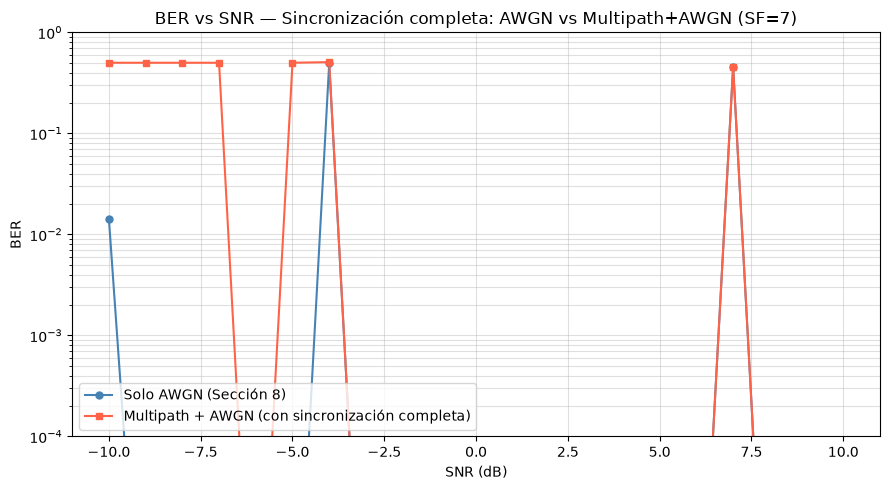


=== Conclusión ===
El sistema de sincronización (detección de preámbulo, alineación de
ventana, corrección de CFO) se mantiene funcional incluso con la
distorsión espectral introducida por el canal multipath, confirmando
que el pipeline completo está listo para probarse con el hardware real
en el notebook 05b_SDR_Real.ipynb, donde el canal físico combinará
ambos efectos de forma natural.


In [45]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogy(snr_range, np.where(ber_loopback > 0, ber_loopback, 1e-7),
            marker='o', markersize=5, linewidth=1.5, color='steelblue',
            label='Solo AWGN (Sección 8)')

ax.semilogy(snr_range_mp, np.where(ber_mp_multipath > 0, ber_mp_multipath, 1e-7),
            marker='s', markersize=5, linewidth=1.5, color='tomato',
            label='Multipath + AWGN (con sincronización completa)')

ax.set_xlabel("SNR (dB)")
ax.set_ylabel("BER")
ax.set_title(f"BER vs SNR — Sincronización completa: AWGN vs Multipath+AWGN (SF={SF})")
ax.legend()
ax.grid(True, which='both', alpha=0.4)
ax.set_ylim(1e-4, 1)
plt.tight_layout()
plt.show()

print("\n=== Conclusión ===")
print("El sistema de sincronización (detección de preámbulo, alineación de")
print("ventana, corrección de CFO) se mantiene funcional incluso con la")
print("distorsión espectral introducida por el canal multipath, confirmando")
print("que el pipeline completo está listo para probarse con el hardware real")
print("en el notebook 05b_SDR_Real.ipynb, donde el canal físico combinará")
print("ambos efectos de forma natural.")